# **Pregunta 13 Parcial 1**
### - Paola Figueroa
### - 2/Marzo/2026

- Aplicar simulaciones para comparar dos estrategias de inversión: aportaciones periódicas frente a inversión única inicial.

- Selecciona un activo financiero y descarga precios históricos de al menos 3 años.

- Define dos estrategias de inversión con un monto total de $5,000:

- Inversión única: se invierte todo el monto al inicio del periodo.

- Inversión periódica (DCA): se invierten $100 cada semana hasta completar $5,000.

- imula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).

- Calcula y compara para ambas estrategias:

    - Valor final promedio de la inversión.

    - Desviación estándar del valor final.

    - Probabilidad de que el valor final sea menor al capital invertido.

- Construye gráficos:

    - Histogramas comparativos de los valores finales.

    - Evolución promedio de la inversión bajo ambas estrategias.

- Redacta un análisis breve, usando markdown en tu notebook, respondiendo:

- ¿En qué condiciones es más ventajosa la inversión periódica?

- ¿Cuándo es preferible la inversión en un solo momento?

In [1]:
# Descargamos las librerías
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [6]:
ticker = "JPM"
prices = yf.download(ticker, start="2023-01-01",progress=False)['Close']
prices.head()

Ticker,JPM
Date,
2023-01-03,124.928696
2023-01-04,126.093689
2023-01-05,126.065742
2023-01-06,128.478073
2023-01-09,127.947136


In [17]:
returns = prices.pct_change().dropna()
mean = returns.mean().iloc[0]
desv_est = returns.std().iloc[0]
S0 = prices.iloc[-1]
S0 = float(S0)

/var/folders/29/_3vm7gk56clb5h32hztvyvzm0000gn/T/ipykernel_14912/2242405473.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(S0)


In [18]:
T = 252 
n_sim = 10000
dt = 1

capital_total = 5000
aporte_semanal = 100
semanas = capital_total // aporte_semanal

np.random.seed(42)
Z = np.random.normal(0, 1, (T, n_sim))

precios_sim = np.zeros((T, n_sim))
precios_sim[0] = S0

for t in range(1, T):
    R_t = mean + desv_est * Z[t]
    precios_sim[t] = precios_sim[t-1] * (1 + R_t)

# Comprar todo al inicio
shares_lump = capital_total / S0
valor_final_lump = shares_lump * precios_sim[-1, :]


#Aportaciones semanales
valor_final_dca = np.zeros(n_sim)
for sim in range(n_sim):
    shares = 0
    for w in range(semanas):
        dia = w * 5  # cada 5 días bursátiles
        if dia < T:
            precio_en_dia = precios_sim[dia, sim]
            shares += aporte_semanal / precio_en_dia
    
    # Valor final al último precio simulado
    valor_final_dca[sim] = shares * precios_sim[-1, sim]

In [22]:
# Métricas comparativas
mean_lump = np.mean(valor_final_lump)
std_lump = np.std(valor_final_lump)
prob_lump = np.mean(valor_final_lump < capital_total)

mean_dca = np.mean(valor_final_dca)
std_dca = np.std(valor_final_dca)
prob_dca = np.mean(valor_final_dca < capital_total)

# poner en data frame
resultados=pd.DataFrame({
    'Métrica': ['Valor final promedio de la inversión',
                'Desviación estándar del valor final',
                'Probabilidad de que el valor final sea menor al capital invertido'],
    'Inversión Única': [mean_lump, std_lump, prob_lump],
    'DCA': [mean_dca, std_dca, prob_dca]
})
print(resultados.to_string(index=False))

                                                          Métrica  Inversión Única         DCA
                             Valor final promedio de la inversión      6753.628924 5859.863812
                              Desviación estándar del valor final      1586.787122  837.804678
Probabilidad de que el valor final sea menor al capital invertido         0.120900    0.147700


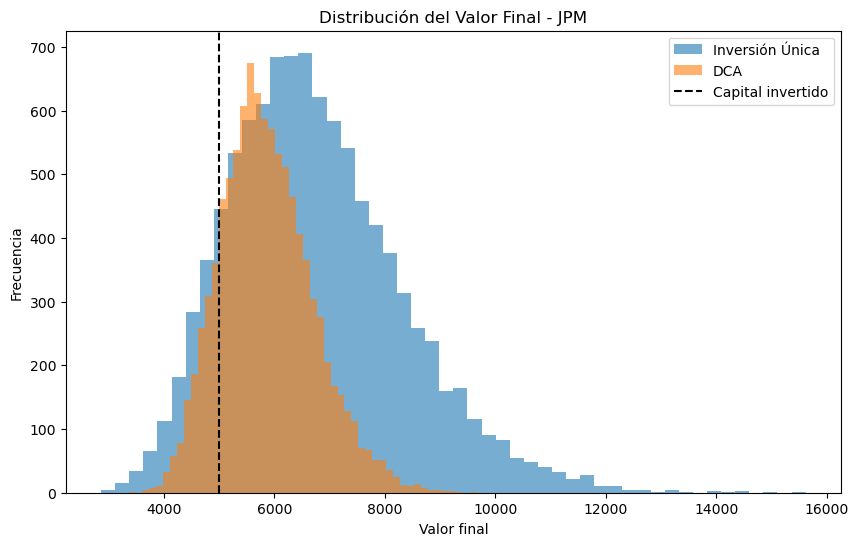

In [23]:
plt.figure(figsize=(10,6))

plt.hist(valor_final_lump, bins=50, alpha=0.6, label="Inversión Única")
plt.hist(valor_final_dca, bins=50, alpha=0.6, label="DCA")

plt.axvline(capital_total, color="black", linestyle="--", label="Capital invertido")

plt.legend()
plt.title("Distribución del Valor Final - JPM")
plt.xlabel("Valor final")
plt.ylabel("Frecuencia")
plt.show()

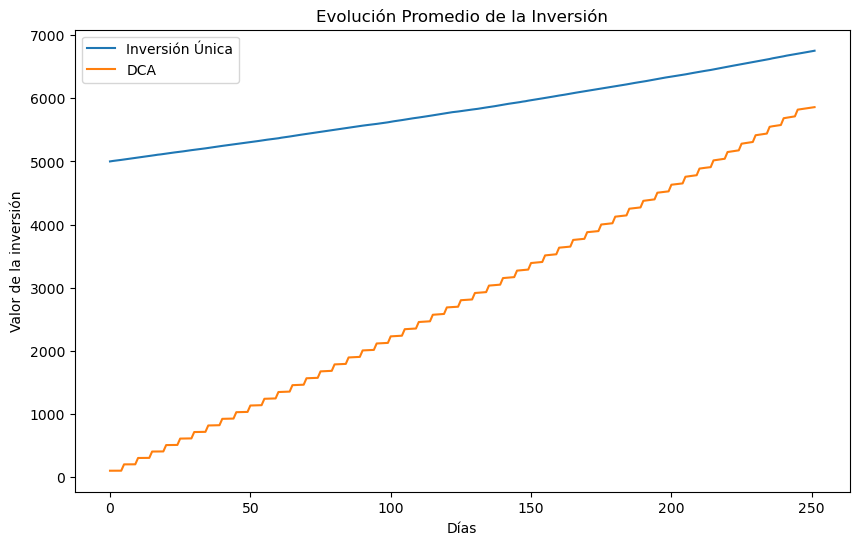

In [24]:
precio_prom = precios_sim.mean(axis=1)
valor_lump_path = shares_lump * precio_prom

shares_dca_path = np.zeros(T)
for w in range(semanas):
    dia = w * 5
    if dia < T:
        shares_dca_path[dia:] += aporte_semanal / precio_prom[dia]

valor_dca_path = shares_dca_path * precio_prom

plt.figure(figsize=(10,6))
plt.plot(valor_lump_path, label="Inversión Única")
plt.plot(valor_dca_path, label="DCA")
plt.title("Evolución Promedio de la Inversión")
plt.xlabel("Días")
plt.ylabel("Valor de la inversión")
plt.legend()
plt.show()

## Preguntas finales

### ¿En qué condiciones es más ventajosa la inversión periódica?

La inversión periódica tiende a ser más conveniente en entornos de alta volatilidad o cuando existe incertidumbre relevante sobre la dirección del mercado. En estos casos, el riesgo de entrar en un punto desfavorable es considerable.  
Al distribuir el capital a lo largo del tiempo, se suaviza el precio promedio de entrada y se reduce la exposición a caídas iniciales pronunciadas. Como resultado, suele observarse una menor desviación estándar en el valor final y una menor probabilidad de pérdidas respecto al capital invertido.  
Por ello, esta estrategia se adapta mejor a perfiles con mayor aversión al riesgo o a escenarios donde no hay una tendencia alcista claramente definida.

### ¿Cuándo es preferible la inversión en un solo momento?

La inversión en un solo momento es más atractiva cuando el activo presenta una tendencia alcista sostenida y el rendimiento esperado es positivo. Invertir todo el capital desde el inicio permite aprovechar el comportamiento compuesto (reinversión) durante todo el horizonte temporal.  
En mercados con crecimiento consistente, esta estrategia suele generar un mayor valor esperado del portafolio. Sin embargo, también implica una mayor varianza en los resultados, ya que el capital queda completamente expuesto desde el principio.  
Es una alternativa más coherente con perfiles de mayor tolerancia al riesgo y con expectativas sólidas de crecimiento del activo.

### Conclusión
En términos generales, la inversión periódica prioriza la estabilidad y la reducción de la varianza del resultado final, mientras que la inversión única busca maximizar el rendimiento esperado en escenarios favorables. La decisión entre ambas depende tanto del contexto de mercado como del perfil de riesgo del inversionista.